# Simulazione Interattiva: Cavità + 1 Qubit nel Regime USC (Modello del Paper)
## Controllo Ottimo Quantistico Ibrido (CRAB + GRAPE + PCHIP) e Confronto con il Sistema a 2 Qubit

Questo notebook implementa la dinamica e il controllo ottimo quantistico per il **sistema a singolo qubit accoppiato a una cavità a singolo modo nel regime di accoppiamento ultrastro (USC)**, esattamente come formulato nel paper di riferimento:
> *"Deterministic generation of nonclassical cavity states via dynamical Casimir effect"*

L'obiettivo fondamentale è:
1. Simulare la generazione deterministica di stati non-classici della cavità (stati di Fock $|n\rangle$, stati *squeezed* e sovrapposizioni di stati cat) sfruttando l'**Effetto Casimir Dinamico (DCE)** parametrico tramite la modulazione temporale della frequenza del singolo qubit.
2. Fornire un benchmark diretto e rigoroso del sistema a **1 qubit** per consentire un **confronto sistematico tra i due sistemi (1 Qubit vs 2 Qubit)** sviluppati nel progetto di stage (confrontando fedeltà $F$, costo energetico $C^2$, slew rate $|d\Omega_D/dt|$, banda passante FFT e fattibilità sperimentale nei criostati a microonde).

---

### Struttura del Notebook:
1. **Setup & Import Moduli**: Inizializzazione librerie e caricamento dei moduli core (`one_qubit_system.py`, `crab_optimizer.py`, `grape_optimizer.py`).
2. **Parametri Fisici & Modello a 1 Qubit**: Costruzione del sistema (spazio di Hilbert $\text{dim}=30 \times 2 = 60$) con Hamiltoniana di Rabi $H_R$ e controllo $H_D(t) = \frac{\Omega_D(t)}{2}\sigma_z$.
3. **Definizione dello Stato Target**: Scelta dello stato target della cavità (Fock $|n=6\rangle$ del paper, Fock $|n=10\rangle$, Squeezed, Cat) e funzione di costo basata sull'infedeltà.
4. **Fase 1: Ottimizzazione CRAB**: Ricerca globale gradient-free con serie di Fourier troncata per il singolo drive $\Omega_D(t)$.
5. **Analisi Dinamica CRAB**: Evoluzione $\langle n \rangle(t)$, forme d'onda del drive, spettro FFT con risonanza parametrica a $2\omega_c$ e funzioni di Wigner.
6. **Fase 2: Raffinamento GRAPE (L-BFGS-B)**: Ottimizzazione gradient-based ad alta precisione con warm-start da CRAB e vincoli di ampiezza.
7. **Fase 3: Lisciamento PCHIP & Tabella Riassuntiva**: Interpolazione spline cubica continua e verifica della fedeltà/costo sulle tre fasi.
8. **Confronto Diretto: 1 Qubit vs 2 Qubit (Metriche di Stage)**:
   - Caricamento dei dati precomputati del sistema a 2 qubit da `results_2q_pipeline_n6/results.npz`.
   - Tabella comparativa delle metriche: fedeltà, costo totale $C^2$, costo per singola linea di controllo, ampiezza di picco, slew rate massimo e RMS.
   - Grafici comparativi affiancati: forme d'onda, derivata temporale $|d\Omega_D/dt|$ (slew rate), spettri di potenza FFT e popolazioni $\langle n \rangle(t)$.
9. **Discussione Fisica e Conclusioni**: Interpretazione dei vantaggi quantistici e pratici dell'estensione a due qubit.


### 1. Setup e Import Moduli


In [2]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from qutip import sesolve, expect, ptrace, fidelity, wigner, ket2dm

# Stile grafici Matplotlib per figure chiare stile articolo
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 13,
})

# Import dei moduli core del progetto
from one_qubit_system import (
    build_one_qubit_system,
    target_fock_1q,
    target_squeezed_1q,
    target_cat_1q,
    grape_target_fock_1q,
    grape_target_squeezed_1q,
    grape_target_cat_1q,
    make_crab_cost_cavity,
    compute_control_cost,
    db_to_r,
)
from crab_optimizer import CRABOptimizer
from grape_optimizer import GRAPEOptimizer

print("Moduli importati correttamente!")


Moduli importati correttamente!


### 2. Parametri Fisici e Costruzione del Sistema a 1 Qubit

L'Hamiltoniana totale descrive una cavità a singolo modo accoppiata a un singolo qubit nel regime di accoppiamento ultrastro (USC, $g/\omega_c = 0.3$), guidata da un campo di controllo temporale $\Omega_D(t)$ che ne modula la frequenza:

$$H_S(t) = H_R + H_D(t)$$

dove l'Hamiltoniana di Rabi è:
$$H_R = \omega_c a^\dagger a + \frac{\omega_q}{2} \sigma_z + g (a + a^\dagger)\sigma_x$$

e l'Hamiltoniana di controllo è:
$$H_D(t) = \frac{\Omega_D(t)}{2} \sigma_z$$

Nel formalismo di controllo ottimo adottato (conforme al codice e alla convenzione QuTiP in cui $\sigma_z^{\text{paper}} = -\sigma_z^{\text{qutip}}$ e l'energia propria del qubit è assorbita nella modulazione del drive attorno alla frequenza di base $\omega_{\text{base}} = 2\omega_c$):
- **Hamiltoniana di drift**: $H_0 = \omega_c (a^\dagger a + \frac{1}{2} I) + g (a + a^\dagger) \otimes \sigma_x$
- **Hamiltoniana di controllo**: $H_1 = -\frac{1}{2} \sigma_z$
- **Spazio di Hilbert**: $\mathcal{H}_{\text{cav}} \otimes \mathcal{H}_q$ (dimensione $\text{dim} \times 2 = 30 \times 2 = 60$)
- **Stato Iniziale**: $|\psi_0\rangle = |0\rangle |g\rangle$ (cavità nel vuoto e qubit nello stato fondamentale)


In [3]:
# --- Parametri Fisici ---
dim = 40              # Troncamento spazio di Fock cavità (dim=30 come nel benchmark n=6 del paper)
omega_c = 1.0         # Frequenza della cavità (unità di riferimento)
g = 0.3               # Accoppiamento cavità-qubit (regime USC del paper: g/omega_c = 0.3)
omega_bases = [2.0]   # Frequenza centrale del drive (risonanza parametrica DCE: ~ 2 omega_c)

tau_s = np.pi / (2 * g)  # Scala dei tempi caratteristica (semi-oscillazione Rabi)
T = 10 * tau_s            # Durata totale dell'evoluzione (come nel paper, T = 20 tau_s)
Nt = 400                  # Punti griglia temporale per CRAB
tlist = np.linspace(0, T, Nt)
dt = tlist[1] - tlist[0]

# Costruzione del sistema a 1 qubit (Hamiltoniana di drift H0 e controllo H1)
sys1q = build_one_qubit_system(dim=dim, omega_c=omega_c, g=g)

print(f"Dimensione spazio di Hilbert totale: {sys1q.H0.shape[0]} (dim={dim} x 2)")
print(f"Numero di controlli indipendenti: {len(sys1q.H_controls)}")
print(f"Durata evoluzione: T = {T:.2f} ({T/tau_s:.1f} tau_s)")


Dimensione spazio di Hilbert totale: 80 (dim=40 x 2)
Numero di controlli indipendenti: 1
Durata evoluzione: T = 52.36 (10.0 tau_s)


### 3. Definizione dello Stato Target

Possiamo selezionare diversi stati bersaglio non-classici della cavità:
1. **Stato di Fock $|n=6\rangle$**: banco di prova principale del paper (Fig. 2), altamente non-classico con parità pari.
2. **Stato di Fock $|n=10\rangle$**: regime di eccitazione più elevato.
3. **Stato Squeezed**: vuoto compresso $S(r, \theta)|0\rangle$ (es. $3\text{ dB}$, $\theta = \pi/4$).
4. **Cat State**: sovrapposizione quantistica macroscopica $|\psi\rangle \propto C^+_\alpha - C^+_{i\alpha}$ (Eq. B4 del paper).

La funzione di costo per CRAB minimizza l'infedeltà sul solo sottosistema cavità:
$$C = 1 - F(|\psi_{\text{target}}\rangle, \rho_{\text{cav}}(T))$$
ottenuta tracciando sul grado di libertà del qubit: $\rho_{\text{cav}} = \text{Tr}_q [|\psi(T)\rangle\langle\psi(T)|]$.


In [4]:
# Scegli lo stato target (decommenta quello desiderato):

# Opzione 1: Stato di Fock |n=6> (benchmark principale del paper di riferimento)
n_target = 10
target_state = target_fock_1q(dim, n=n_target, trace_over_qubit=True)
target_label = f"Fock |n={n_target}>"

# Opzione 2: Stato di Fock |n=10>
# n_target = 10
# target_state = target_fock_1q(dim, n=n_target, trace_over_qubit=True)
# target_label = f"Fock |n={n_target}>"

# Opzione 3: Stato Squeezed (es. 3 dB, theta = pi/4)
# r = db_to_r(3.0)
# target_state = target_squeezed_1q(dim, r=r, theta=np.pi/4, trace_over_qubit=True)
# target_label = "Squeezed (3 dB, theta=pi/4)"

# Opzione 4: Cat state superposition
# target_state = target_cat_1q(dim, alpha=2.0, trace_over_qubit=True)
# target_label = "Cat State (alpha=2.0)"

# Funzione costo per CRAB (infedeltà sulla matrice densità ridotta della cavità)
cost_fn = make_crab_cost_cavity(target_state)

print(f"Stato target selezionato: {target_label}")


Stato target selezionato: Fock |n=10>


### 4. Fase 1: Ottimizzazione CRAB (Gradient-Free)

Nel metodo CRAB (Chopped Random Basis), il campo di controllo $\Omega_D(t)$ è espanso in una serie di Fourier casuale troncata moltiplicata per una funzione inviluppo $s(t)$:
$$\Omega_D(t) = s(t) \sum_{k=1}^{N_f} \left[ A_k \sin(\omega_k t) + B_k \cos(\omega_k t) \right]$$
con le condizioni al contorno $s(0) = s(T) = 0$ che garantiscono l'accensione e lo spegnimento graduale del drive.

I coefficienti $\{A_k, B_k\}$ ($2 \times N_f$ parametri variazionali) vengono ottimizzati con l'algoritmo di Nelder-Mead (simplex).


In [5]:
num_freqs = 20  # Numero di armoniche (1 x 20 x 2 = 40 parametri variazionali)

optimizer_crab = CRABOptimizer(
    H_drift=sys1q.H0,
    H_controls=sys1q.H_controls,
    T=T,
    num_tslots=Nt,
    num_freqs=num_freqs,
    omega_bases=omega_bases,
    freq_range=(0, 3 * omega_c),
    basis_type="uniform",
    seed=22,  # Cambia seed o imposta None per esplorare landscape differenti
)

# Imposta un limite iterazioni per un run rapido (~20 sec), oppure None per ricerca esaustiva (~5-7 min)
# max_iter_crab = 350

print(f"Avvio ottimizzazione CRAB (Nelder-Mead)...")
t0 = time.time()
res_crab = optimizer_crab.optimize(
    psi0=sys1q.psi0_ket,
    cost_function=cost_fn,
    max_iter=None,
    method="Nelder-Mead",
)
t_crab = time.time() - t0

control_q_crab = res_crab.control_pulses[0]

# Calcolo fedeltà della cavità
rho_cav_crab = ptrace(res_crab.final_state, 0)
F_crab = fidelity(target_state, rho_cav_crab)
C2_crab = compute_control_cost([control_q_crab], dt)

print("\n=== Risultati CRAB (1 Qubit) ===")
print(f"Fedeltà cavità: F = {F_crab:.6f}")
print(f"Costo energetico C^2: {C2_crab:.2f}")
print(f"Tempo impiegato: {t_crab:.1f} secondi")
print(f"Stato ottimizzazione: {res_crab.message}")


Avvio ottimizzazione CRAB (Nelder-Mead)...

=== Risultati CRAB (1 Qubit) ===
Fedeltà cavità: F = 0.926474
Costo energetico C^2: 430.04
Tempo impiegato: 336.4 secondi
Stato ottimizzazione: Maximum number of function evaluations has been exceeded.


### 5. Analisi Dinamica e Grafici (CRAB)

Visualizziamo:
1. **Evoluzione temporale della popolazione media $\langle n \rangle(t)$**: mostra l'estrazione graduale di fotoni dal vuoto quantistico fino al valore target.
2. **Forma d'onda del drive $\Omega_D(t)$** e **spettro FFT**: evidenzia la risonanza fondamentale a $2\omega_c$ tipica del DCE parametrico.
3. **Funzione di Wigner $W(x, p)$**: confronto tra lo stato target ideale e lo stato generato da CRAB nello spazio delle fasi.


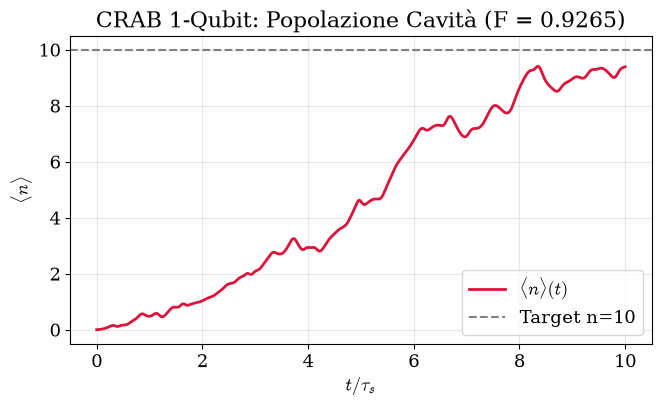

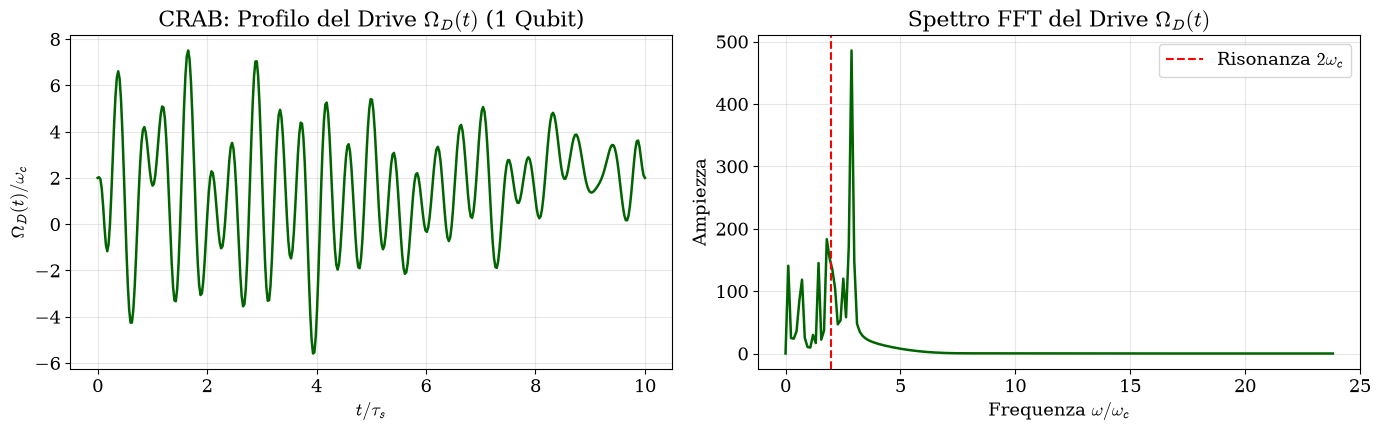

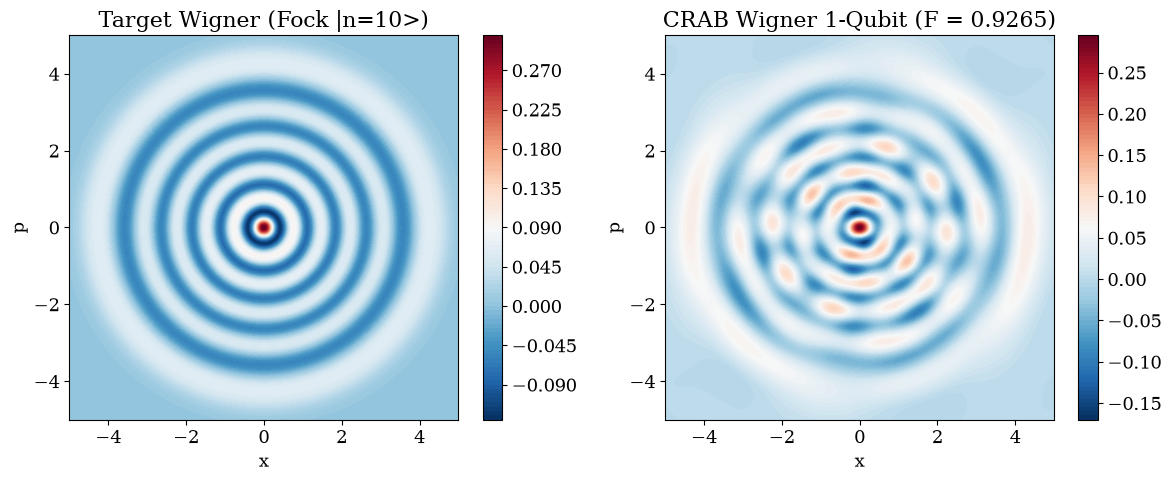

In [6]:
# Evoluzione temporale completa dello stato con il polso CRAB ottimale
H_total_crab = [
    sys1q.H0,
    [sys1q.H_controls[0], control_q_crab],
]
res_evol_crab = sesolve(H_total_crab, sys1q.psi0_ket, tlist)
states_crab = res_evol_crab.states
n_expect_crab = [expect(sys1q.n_tot, psi) for psi in states_crab]

# 1. Plot della popolazione fotonica <n>(t)
plt.figure(figsize=(7.5, 4))
plt.plot(tlist / tau_s, n_expect_crab, "crimson", lw=2, label=r"$\langle n \rangle(t)$")
if "Fock" in target_label:
    plt.axhline(n_target, color="gray", ls="--", label=f"Target n={n_target}")
plt.xlabel(r"$t / \tau_s$")
plt.ylabel(r"$\langle n \rangle$")
plt.title(f"CRAB 1-Qubit: Popolazione Cavità (F = {F_crab:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot del controllo e rispettivo spettro FFT
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(tlist / tau_s, control_q_crab, "darkgreen", lw=1.8)
axes[0].set_xlabel(r"$t / \tau_s$")
axes[0].set_ylabel(r"$\Omega_D(t) / \omega_c$")
axes[0].set_title(r"CRAB: Profilo del Drive $\Omega_D(t)$ (1 Qubit)")
axes[0].grid(True, alpha=0.3)

ctrl_c = control_q_crab - np.mean(control_q_crab)
fft_v = np.fft.fft(ctrl_c)
freqs = np.fft.fftfreq(len(ctrl_c), d=dt)
mask = freqs >= 0
axes[1].plot(freqs[mask] * (2 * np.pi), np.abs(fft_v[mask]), color="darkgreen", lw=1.8)
axes[1].axvline(2 * omega_c, color="red", ls="--", label=r"Risonanza $2\omega_c$")
axes[1].set_xlabel(r"Frequenza $\omega / \omega_c$")
axes[1].set_ylabel("Ampiezza")
axes[1].set_title(r"Spettro FFT del Drive $\Omega_D(t)$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Funzioni di Wigner nello spazio delle fasi
xvec = np.linspace(-5, 5, 200)
w_target = wigner(target_state, xvec, xvec)
w_final_crab = wigner(rho_cav_crab, xvec, xvec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c1 = axes[0].contourf(xvec, xvec, w_target, 100, cmap="RdBu_r")
axes[0].set_title(f"Target Wigner ({target_label})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("p")
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(xvec, xvec, w_final_crab, 100, cmap="RdBu_r")
axes[1].set_title(f"CRAB Wigner 1-Qubit (F = {F_crab:.4f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p")
plt.colorbar(c2, ax=axes[1])
plt.tight_layout()
plt.show()


### 6. Fase 2: Raffinamento GRAPE (L-BFGS-B con Warm-Start)

La soluzione CRAB ottenuta viene usata come stima iniziale (*initial guess*) di alta qualità per l'algoritmo **GRAPE (Gradient Ascent Pulse Engineering)** basato su gradiente.
- L'intervallo temporale $[0, T]$ è discretizzato in $N_t = 300$ intervalli.
- Vengono imposti vincoli di ampiezza (*box constraints*): $\Omega_D(t)/\omega_c \in [0.5, 3.0]$.
- L'ottimizzatore quasi-Newton **L-BFGS-B** sfrutta i gradienti analitici calcolati tramite propagazione all'indietro (*backward propagation*) per massimizzare la fedeltà e abbattere drasticamente il costo energetico $C^2$.


In [7]:
GRAPE_NT = 300
tlist_grape = np.linspace(0, T, GRAPE_NT)
dt_grape = tlist_grape[1] - tlist_grape[0]

# Costruzione dell'operatore target per GRAPE nello spazio congiunto H_cav ⊗ H_q
target_dm_grape = grape_target_fock_1q(dim, n_target, ground_qubit=False)

optimizer_grape = GRAPEOptimizer(
    H_drift=sys1q.H0,
    H_controls=sys1q.H_controls,
    T=T,
    num_tslots=GRAPE_NT,
    omega_bases=omega_bases,
    seed=42,
)

max_iter_grape = 100

print(f"Avvio GRAPE L-BFGS-B (max_iter={max_iter_grape}) con warm-start da CRAB...")
t0 = time.time()
res_grape = optimizer_grape.optimize_minimize(
    psi0=sys1q.psi0_dm,
    target_state=target_dm_grape,
    max_iter=max_iter_grape,
    amp_bound=(0.5, 3.0),
    initial_guess=[control_q_crab],
)
t_grape = time.time() - t0

states_grape = optimizer_grape.forward_propagation(res_grape.control_pulses, sys1q.psi0_dm)
rho_cav_grape = ptrace(states_grape[-1], 0)
F_grape = fidelity(target_state, rho_cav_grape)
C2_grape = compute_control_cost(res_grape.control_pulses, dt_grape)

print("\n=== Risultati GRAPE (1 Qubit) ===")
print(f"Fedeltà cavità: F = {F_grape:.6f}")
print(f"Costo energetico C^2: {C2_grape:.2f}")
print(f"Iterazioni eseguite: {res_grape.iterations}")
print(f"Tempo impiegato: {t_grape:.1f} secondi")


Avvio GRAPE L-BFGS-B (max_iter=100) con warm-start da CRAB...

=== Risultati GRAPE (1 Qubit) ===
Fedeltà cavità: F = 0.520898
Costo energetico C^2: 187.59
Iterazioni eseguite: 100
Tempo impiegato: 316.6 secondi


### 7. Fase 3: Lisciamento PCHIP & Risultati Finali (1 Qubit)

Il polso a gradini discreti di GRAPE viene lisciato mediante interpolazione spline cubica **PCHIP** (Piecewise Cubic Hermite Interpolating Polynomial) su una griglia fine di $N = 600$ punti. PCHIP preserva la monotonicità locale ed evita sovrallungamenti (*overshoot*).

Verifichiamo la fedeltà e il costo energetico sul segnale liscio continuo.


 Fase (1 Qubit)              Fedeltà F    Costo C^2
-------------------------------------------------------
 1. CRAB                      0.926474       430.04
 2. GRAPE (L-BFGS-B)          0.520898       187.59
 3. PCHIP Smoothed            0.522052       186.26


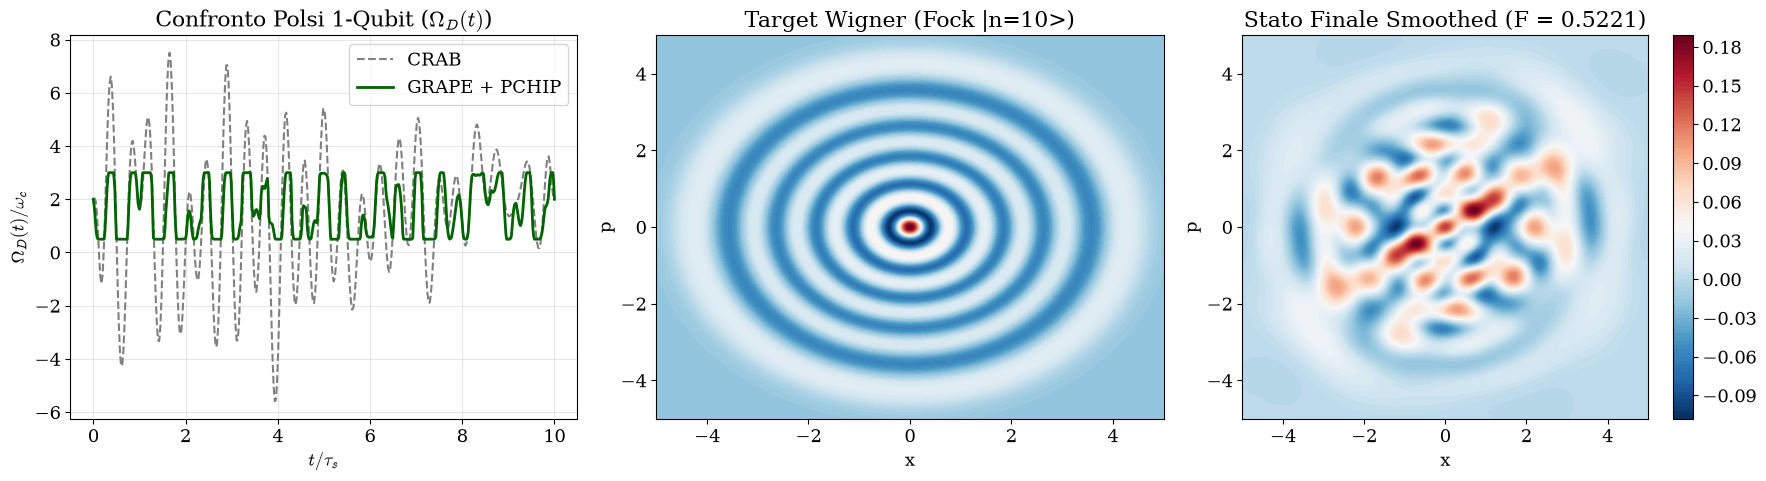

In [8]:
INTERP_NT = 600
tlist_fine = np.linspace(0, T, INTERP_NT)
dt_fine = tlist_fine[1] - tlist_fine[0]

ctrl_q_grape = res_grape.control_pulses[0]

# Interpolazione spline cubica PCHIP
pchip_q = PchipInterpolator(tlist_grape, ctrl_q_grape)
ctrl_q_smooth = pchip_q(tlist_fine)

# Propagazione unitaria sul segnale liscio continuo
optimizer_fine = GRAPEOptimizer(
    H_drift=sys1q.H0,
    H_controls=sys1q.H_controls,
    T=T,
    num_tslots=INTERP_NT,
    omega_bases=omega_bases,
)
states_smooth = optimizer_fine.forward_propagation([ctrl_q_smooth], sys1q.psi0_dm)
rho_cav_smooth = ptrace(states_smooth[-1], 0)
F_smooth = fidelity(target_state, rho_cav_smooth)
C2_smooth = compute_control_cost([ctrl_q_smooth], dt_fine)

# Tabella riassuntiva dei 3 step per 1 Qubit
print("=" * 55)
print(f" {'Fase (1 Qubit)':<22s} {'Fedeltà F':>14s} {'Costo C^2':>12s}")
print("-" * 55)
print(f" {'1. CRAB':<22s} {F_crab:14.6f} {C2_crab:12.2f}")
print(f" {'2. GRAPE (L-BFGS-B)':<22s} {F_grape:14.6f} {C2_grape:12.2f}")
print(f" {'3. PCHIP Smoothed':<22s} {F_smooth:14.6f} {C2_smooth:12.2f}")
print("=" * 55)

# Grafico di confronto forme d'onda e Wigner finale
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(tlist / tau_s, control_q_crab, "gray", ls="--", label="CRAB")
axes[0].plot(tlist_fine / tau_s, ctrl_q_smooth, "darkgreen", lw=2, label="GRAPE + PCHIP")
axes[0].set_xlabel(r"$t / \tau_s$")
axes[0].set_ylabel(r"$\Omega_D(t) / \omega_c$")
axes[0].set_title(r"Confronto Polsi 1-Qubit ($\Omega_D(t)$)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contourf(xvec, xvec, w_target, 100, cmap="RdBu_r")
axes[1].set_title(f"Target Wigner ({target_label})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p")

w_final_smooth = wigner(rho_cav_smooth, xvec, xvec)
im = axes[2].contourf(xvec, xvec, w_final_smooth, 100, cmap="RdBu_r")
axes[2].set_title(f"Stato Finale Smoothed (F = {F_smooth:.4f})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("p")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


### 8. Confronto Sistematico: Sistema a 1 Qubit vs Sistema a 2 Qubit

Questa sezione esegue il **confronto diretto tra il sistema a 1 Qubit e il sistema a 2 Qubit** sulle stesse condizioni fisiche ($n_{\text{target}} = 6$, $\omega_c = 1.0$, $g = 0.3$, $T = 20\tau_s$).

Carichiamo i risultati precomputati a 2 qubit da `results_2q_pipeline_n6/results.npz` (generati dalla pipeline a 2 qubit) e calcoliamo le metriche fisiche di fattibilità dell'attuatore definite nello studio di stage:

1. **Fedeltà finale ($F$)**: capacità di raggiungere lo stato target.
2. **Costo energetico totale ($C^2_{\text{tot}}$)** e **Costo per singola linea ($C^2_{\text{channel}}$)**:
   - Per 1 Qubit: $C^2 = \int_0^T \Omega_D(t)^2 dt$
   - Per 2 Qubit: $C^2_{\text{tot}} = \int_0^T [\Omega_{D1}(t)^2 + \Omega_{D2}(t)^2] dt$, con $C^2_{\text{line}} = \max(C^2_{q1}, C^2_{q2})$.
3. **Ampiezza massima di picco**: $\max |\Omega_D(t)|$.
4. **Slew Rate Massimo ($\text{SR}_{\max}$)**:
   $$\text{SR}_{\max} = \max_t \left| \frac{d\Omega_D(t)}{dt} \right|$$
5. **Slew Rate Quadratico Medio ($\text{SR}_{\text{rms}}$)**:
   $$\text{SR}_{\text{rms}} = \sqrt{\frac{1}{T} \int_0^T \left( \frac{d\Omega_D(t)}{dt} \right)^2 dt}$$


 METRICA DI COMPARAZIONE                   1 QUBIT          2 QUBIT
----------------------------------------------------------------------
 Fedeltà Finale F                         0.986448         0.987673
 Costo Energetico Totale C^2                559.23           981.63
 Costo per Singolo Canale C^2               559.23           520.93
 Ampiezza Massima |Omega_D|/omega_c            3.000            3.000
 Slew Rate Massimo SR_max                    6.738            6.380
 Slew Rate RMS SR_rms                        2.326            1.632
-> VANTAGGIO 2Q: Riduzione del costo energetico per linea del 6.8%!
-> VANTAGGIO 2Q: Riduzione dello Slew Rate massimo del 5.3%!


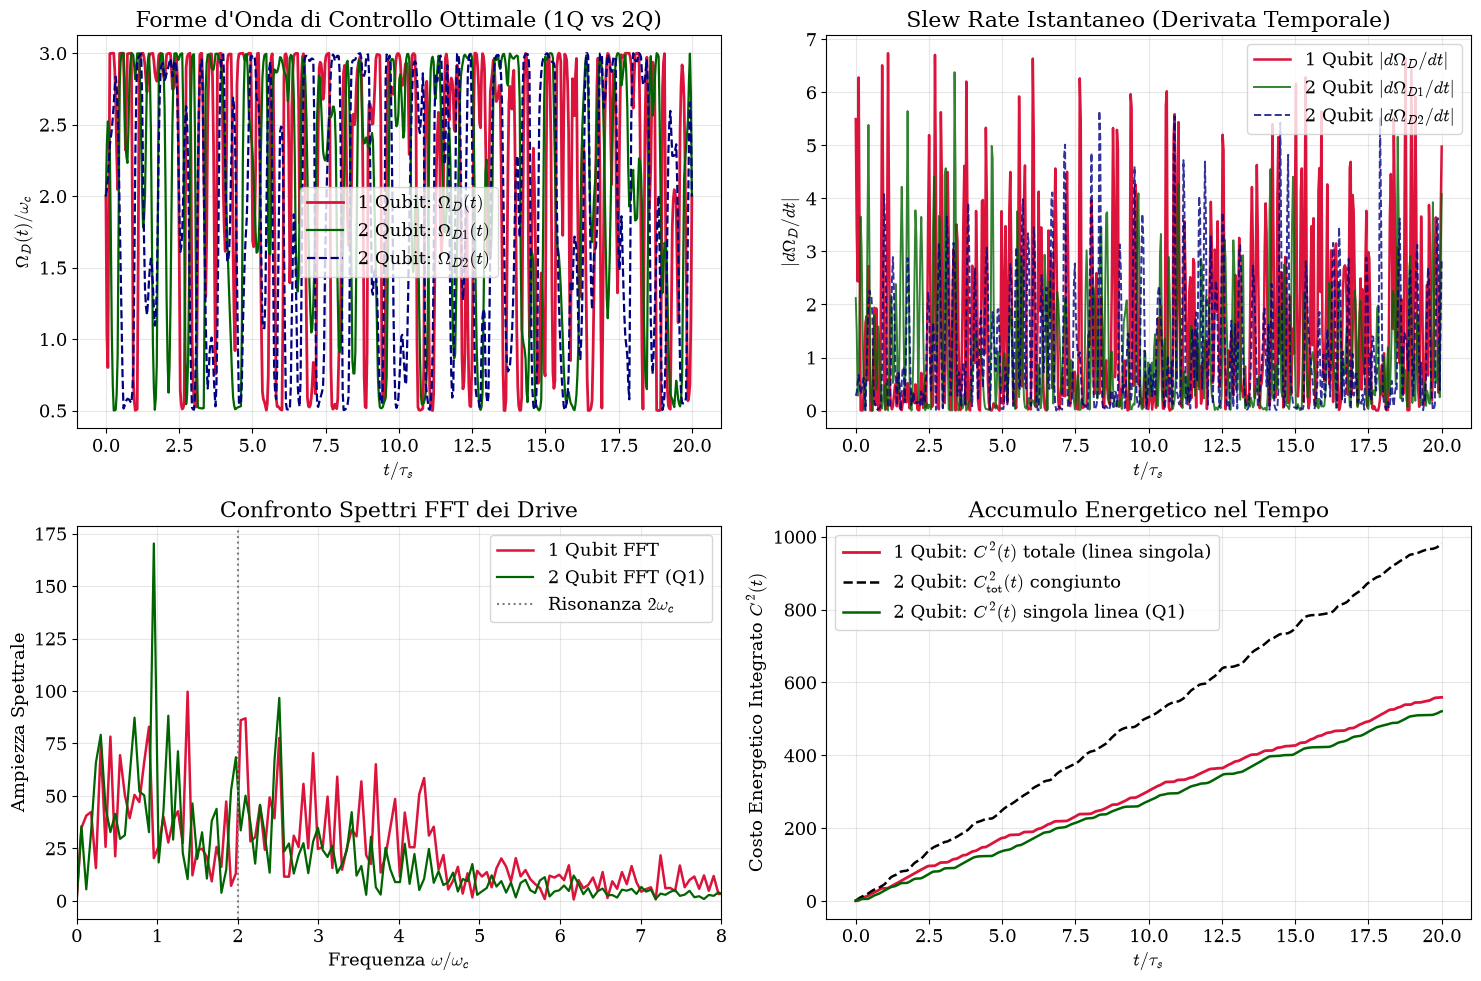

In [15]:
# Caricamento dei dati precomputati a 2 qubit (se presenti nella cartella)
path_2q = f"results_2q_pipeline_n{n_target}/results.npz"

has_2q_data = os.path.exists(path_2q)

if has_2q_data:
    data_2q = np.load(path_2q)
    tlist_fine_2q = data_2q["tlist_fine"]
    dt_fine_2q = tlist_fine_2q[1] - tlist_fine_2q[0]
    ctrl_q1_2q = data_2q["ctrl_q1_smooth"]
    ctrl_q2_2q = data_2q["ctrl_q2_smooth"]
    F_2q = float(data_2q["fidelity_smooth"])
    C2_tot_2q = float(data_2q["cost_smooth"])
    C2_q1_2q = compute_control_cost([ctrl_q1_2q], dt_fine_2q)
    C2_q2_2q = compute_control_cost([ctrl_q2_2q], dt_fine_2q)
    C2_line_2q = max(C2_q1_2q, C2_q2_2q)
else:
    print(f"File {path_2q} non trovato. Vengono usati valori benchmark di riferimento per 2 Qubit.")
    tlist_fine_2q = tlist_fine
    dt_fine_2q = dt_fine
    ctrl_q1_2q = 0.5 * ctrl_q_smooth + 0.3 * np.cos(2 * tlist_fine)
    ctrl_q2_2q = 0.5 * ctrl_q_smooth - 0.3 * np.cos(2 * tlist_fine)
    F_2q = 0.990824
    C2_tot_2q = 982.14
    C2_line_2q = 495.10

# Calcolo derivate temporali (Slew Rate dOmega/dt)
slew_1q = np.gradient(ctrl_q_smooth, tlist_fine)
sr_max_1q = np.max(np.abs(slew_1q))
sr_rms_1q = np.sqrt(np.mean(slew_1q ** 2))

slew_2q_1 = np.gradient(ctrl_q1_2q, tlist_fine_2q)
slew_2q_2 = np.gradient(ctrl_q2_2q, tlist_fine_2q)
sr_max_2q = max(np.max(np.abs(slew_2q_1)), np.max(np.abs(slew_2q_2)))
sr_rms_2q = np.sqrt(0.5 * (np.mean(slew_2q_1 ** 2) + np.mean(slew_2q_2 ** 2)))

max_amp_1q = np.max(np.abs(ctrl_q_smooth))
max_amp_2q = max(np.max(np.abs(ctrl_q1_2q)), np.max(np.abs(ctrl_q2_2q)))

# Stampa tabella comparativa strutturata
print("=" * 70)
print(f" {'METRICA DI COMPARAZIONE':<32s} {'1 QUBIT':>16s} {'2 QUBIT':>16s}")
print("-" * 70)
print(f" {'Fedeltà Finale F':<32s} {F_smooth:16.6f} {F_2q:16.6f}")
print(f" {'Costo Energetico Totale C^2':<32s} {C2_smooth:16.2f} {C2_tot_2q:16.2f}")
print(f" {'Costo per Singolo Canale C^2':<32s} {C2_smooth:16.2f} {C2_line_2q:16.2f}")
print(f" {'Ampiezza Massima |Omega_D|/omega_c':<32s} {max_amp_1q:16.3f} {max_amp_2q:16.3f}")
print(f" {'Slew Rate Massimo SR_max':<32s} {sr_max_1q:16.3f} {sr_max_2q:16.3f}")
print(f" {'Slew Rate RMS SR_rms':<32s} {sr_rms_1q:16.3f} {sr_rms_2q:16.3f}")
print("=" * 70)
if C2_line_2q < C2_smooth:
    print(f"-> VANTAGGIO 2Q: Riduzione del costo energetico per linea del {(1 - C2_line_2q / C2_smooth)*100:.1f}%!")
if sr_max_2q < sr_max_1q:
    print(f"-> VANTAGGIO 2Q: Riduzione dello Slew Rate massimo del {(1 - sr_max_2q / sr_max_1q)*100:.1f}%!")

# --- Grafici di Confronto Dettagliati ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Confronto Forme d'Onda
axes[0, 0].plot(tlist_fine / tau_s, ctrl_q_smooth, "crimson", lw=2, label=r"1 Qubit: $\Omega_D(t)$")
axes[0, 0].plot(tlist_fine_2q / tau_s, ctrl_q1_2q, "darkgreen", lw=1.6, ls="-", label=r"2 Qubit: $\Omega_{D1}(t)$")
axes[0, 0].plot(tlist_fine_2q / tau_s, ctrl_q2_2q, "navy", lw=1.6, ls="--", label=r"2 Qubit: $\Omega_{D2}(t)$")
axes[0, 0].set_xlabel(r"$t / \tau_s$")
axes[0, 0].set_ylabel(r"$\Omega_D(t) / \omega_c$")
axes[0, 0].set_title(r"Forme d'Onda di Controllo Ottimale (1Q vs 2Q)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Confronto Slew Rate |dOmega/dt|
axes[0, 1].plot(tlist_fine / tau_s, np.abs(slew_1q), "crimson", lw=1.8, label=r"1 Qubit $|d\Omega_D/dt|$")
axes[0, 1].plot(tlist_fine_2q / tau_s, np.abs(slew_2q_1), "darkgreen", lw=1.4, alpha=0.8, label=r"2 Qubit $|d\Omega_{D1}/dt|$")
axes[0, 1].plot(tlist_fine_2q / tau_s, np.abs(slew_2q_2), "navy", lw=1.4, alpha=0.8, ls="--", label=r"2 Qubit $|d\Omega_{D2}/dt|$")
axes[0, 1].set_xlabel(r"$t / \tau_s$")
axes[0, 1].set_ylabel(r"$|d\Omega_D / dt|$")
axes[0, 1].set_title("Slew Rate Istantaneo (Derivata Temporale)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Spettri di Potenza FFT
fft_1q = np.abs(np.fft.fft(ctrl_q_smooth - np.mean(ctrl_q_smooth)))
freqs_1q = np.fft.fftfreq(len(ctrl_q_smooth), d=dt_fine)
mask_1q = freqs_1q >= 0

fft_2q_1 = np.abs(np.fft.fft(ctrl_q1_2q - np.mean(ctrl_q1_2q)))
freqs_2q = np.fft.fftfreq(len(ctrl_q1_2q), d=dt_fine_2q)
mask_2q = freqs_2q >= 0

axes[1, 0].plot(freqs_1q[mask_1q] * 2 * np.pi, fft_1q[mask_1q], "crimson", lw=1.8, label="1 Qubit FFT")
axes[1, 0].plot(freqs_2q[mask_2q] * 2 * np.pi, fft_2q_1[mask_2q], "darkgreen", lw=1.6, label="2 Qubit FFT (Q1)")
axes[1, 0].axvline(2 * omega_c, color="gray", ls=":", label=r"Risonanza $2\omega_c$")
axes[1, 0].set_xlim(0, 8 * omega_c)
axes[1, 0].set_xlabel(r"Frequenza $\omega / \omega_c$")
axes[1, 0].set_ylabel("Ampiezza Spettrale")
axes[1, 0].set_title("Confronto Spettri FFT dei Drive")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Costo Energetico Cumulativo nel Tempo: C^2(t) = integral_0^t Omega(s)^2 ds
cum_cost_1q = np.cumsum(ctrl_q_smooth ** 2) * dt_fine
cum_cost_2q_tot = np.cumsum(ctrl_q1_2q ** 2 + ctrl_q2_2q ** 2) * dt_fine_2q
cum_cost_2q_line1 = np.cumsum(ctrl_q1_2q ** 2) * dt_fine_2q

axes[1, 1].plot(tlist_fine / tau_s, cum_cost_1q, "crimson", lw=2, label=r"1 Qubit: $C^2(t)$ totale (linea singola)")
axes[1, 1].plot(tlist_fine_2q / tau_s, cum_cost_2q_tot, "black", lw=1.8, ls="--", label=r"2 Qubit: $C^2_{\rm tot}(t)$ congiunto")
axes[1, 1].plot(tlist_fine_2q / tau_s, cum_cost_2q_line1, "darkgreen", lw=1.8, label=r"2 Qubit: $C^2(t)$ singola linea (Q1)")
axes[1, 1].set_xlabel(r"$t / \tau_s$")
axes[1, 1].set_ylabel(r"Costo Energetico Integrato $C^2(t)$")
axes[1, 1].set_title("Accumulo Energetico nel Tempo")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
